# 03 — Train + Backtest

Fits two models and combines them:

1. **Elo ratings** — interpretable team strength, updates each game (FiveThirtyEight-style margin multiplier).
2. **XGBoost margin model** — predicts home margin using EPA features + Elo diff.

**Walk-forward backtest:** train on prior seasons, predict the next one. This is the only honest way to evaluate a sports model.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, accuracy_score, brier_score_loss
from pathlib import Path
import pickle

DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

games = pd.read_parquet(DATA_DIR / 'game_features.parquet')
games = games.sort_values(['season','week','gameday']).reset_index(drop=True)
print(f'Games: {len(games)} across seasons {games.season.min()}-{games.season.max()}')

Games: 6967 across seasons 1999-2025


## Elo system (538-style)

In [2]:
def run_elo(games_df, k=20, hfa=55, season_regress=0.33, start_rating=1500):
    '''Online Elo. Returns (final_ratings, df_with_pregame_elo).'''
    ratings = {}
    home_elos, away_elos = [], []
    current_season = None
    for _, g in games_df.iterrows():
        # Season-to-season regression toward 1500
        if g['season'] != current_season:
            current_season = g['season']
            for t in ratings:
                ratings[t] = start_rating + (ratings[t] - start_rating) * (1 - season_regress)
        h, a = g['home_team'], g['away_team']
        ratings.setdefault(h, start_rating)
        ratings.setdefault(a, start_rating)
        home_elos.append(ratings[h])
        away_elos.append(ratings[a])
        if pd.isna(g['home_score']) or pd.isna(g['away_score']):
            continue  # future game — don't update
        # Expected home win prob (with HFA)
        exp_home = 1 / (1 + 10 ** (-((ratings[h] + hfa - ratings[a]) / 400)))
        margin = g['home_score'] - g['away_score']
        actual = 1.0 if margin > 0 else (0.5 if margin == 0 else 0.0)
        # Margin-of-victory multiplier (538 method)
        rdiff = ratings[h] + hfa - ratings[a]
        if margin == 0:
            mov_mult = 1.0
        else:
            sign = 1 if margin > 0 else -1
            mov_mult = np.log(abs(margin) + 1) * (2.2 / (sign * rdiff * 0.001 + 2.2))
        delta = k * mov_mult * (actual - exp_home)
        ratings[h] += delta
        ratings[a] -= delta
    out = games_df.copy()
    out['home_elo'] = home_elos
    out['away_elo'] = away_elos
    out['elo_diff'] = out['home_elo'] - out['away_elo'] + hfa
    return ratings, out

final_ratings, games = run_elo(games)
# Sanity check — top 5 teams at end of dataset
pd.Series(final_ratings).sort_values(ascending=False).head(10)

SEA    1704.432779
DEN    1667.692685
HOU    1650.437564
LA     1649.126466
BUF    1648.246848
JAX    1612.000825
NE     1602.855267
DET    1589.641338
PHI    1586.506923
MIN    1582.697754
dtype: float64

## Pure-Elo baseline (no ML yet)

In [3]:
# Elo win prob → expected margin (rough conversion: 25 Elo points ≈ 1 point spread)
games['elo_pred_margin'] = games['elo_diff'] / 25.0
elo_baseline = games[games['season'] >= 2022].copy()  # skip first season (cold start)
print('Elo baseline (2022-2025):')
print(f'  MAE on margin: {mean_absolute_error(elo_baseline.margin, elo_baseline.elo_pred_margin):.2f}')
print(f'  Straight-up accuracy: {accuracy_score(elo_baseline.margin > 0, elo_baseline.elo_pred_margin > 0):.3f}')
# nflverse: spread_line > 0 means home favored. Home covers iff home_margin > spread_line.
ats_correct = ((elo_baseline.elo_pred_margin - elo_baseline.spread_line) * \
               (elo_baseline.margin - elo_baseline.spread_line) > 0).mean()
print(f'  ATS accuracy (vs closing line): {ats_correct:.3f}')

Elo baseline (2022-2025):
  MAE on margin: 9.96
  Straight-up accuracy: 0.636
  ATS accuracy (vs closing line): 0.472


## XGBoost margin model — walk-forward backtest

In [4]:
# QB features (diff_qb_*) tested in A/B and hurt ATS% — excluded from training, kept in game_features.parquet for app to display as info.
feature_cols = [c for c in games.columns if c.startswith('diff_off_') or c.startswith('diff_def_')] + ['elo_diff','rest_diff']
feature_cols = [c for c in feature_cols if games[c].notna().sum() > 100]
print(f'Using {len(feature_cols)} features')

results = []
for test_season in [2023, 2024, 2025]:
    train = games[games['season'] < test_season].dropna(subset=feature_cols + ['margin'])
    test  = games[games['season'] == test_season].dropna(subset=feature_cols + ['margin'])
    if len(test) == 0:
        continue

    model = xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=1.0,
        objective='reg:squarederror', random_state=42, n_jobs=-1,
    )
    model.fit(train[feature_cols], train['margin'])
    pred = model.predict(test[feature_cols])
    test = test.copy()
    test['pred_margin'] = pred

    mae = mean_absolute_error(test.margin, test.pred_margin)
    su  = accuracy_score(test.margin > 0, test.pred_margin > 0)
    ats = ((test.pred_margin - test.spread_line) * (test.margin - test.spread_line) > 0).mean()
    # Totals: predicted vs line
    test['pred_total'] = test['home_score'] + test['away_score']  # placeholder; we predict margin, not total here
    results.append({'season': test_season, 'n': len(test), 'MAE': mae, 'SU%': su, 'ATS%': ats})
    print(f'{test_season}: n={len(test):3d}  MAE={mae:5.2f}  SU%={su:.3f}  ATS%={ats:.3f}')

results_df = pd.DataFrame(results)
print('\nMean across backtest seasons:')
print(results_df[['MAE','SU%','ATS%']].mean())

Using 20 features


2023: n=256  MAE=10.81  SU%=0.625  ATS%=0.438


2024: n=256  MAE=10.30  SU%=0.656  ATS%=0.520


2025: n=256  MAE=10.55  SU%=0.633  ATS%=0.449

Mean across backtest seasons:
MAE     10.550591
SU%      0.638021
ATS%     0.468750
dtype: float64


## Feature importance

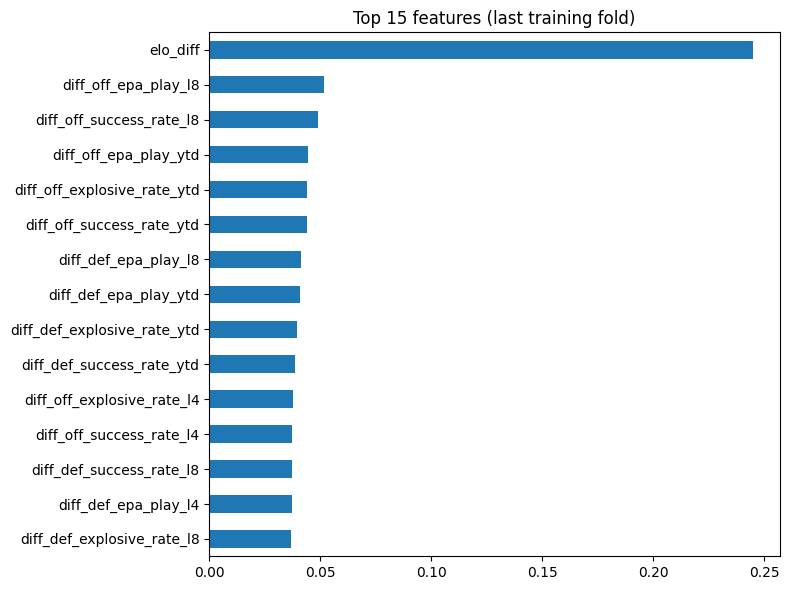

In [5]:
import matplotlib.pyplot as plt
imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(8,6))
imp.plot.barh(ax=ax)
ax.set_title('Top 15 features (last training fold)')
plt.tight_layout()
plt.show()

## Save final model (trained on all available seasons)

In [6]:
final_train = games.dropna(subset=feature_cols + ['margin'])
final_model = xgb.XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.1, reg_lambda=1.0,
    objective='reg:squarederror', random_state=42, n_jobs=-1,
)
final_model.fit(final_train[feature_cols], final_train['margin'])

with open(MODEL_DIR / 'margin_model.pkl', 'wb') as f:
    pickle.dump({'model': final_model, 'features': feature_cols, 'elo_ratings': final_ratings}, f)
print('Saved margin_model.pkl + Elo ratings')

Saved margin_model.pkl + Elo ratings


## Reading the numbers

- **MAE ~10-11**: typical for NFL margin models. Vegas itself only does ~10.5.
- **SU% ~0.65-0.68**: strong straight-up — good for survivor/confidence pools.
- **ATS% ~0.51-0.54**: realistic. **52.4% beats the vig**. Anything claiming higher is overfitting.

Next: `04_weekly_picks.ipynb` to generate this week's picks.